# Customer Intelligence & Segmentation Platform

## Notebook 02: Exploratory Data Analysis (EDA)

### Objective

The goal of this notebook is to analyze customer behavior, sales trends, product performance, and geographic patterns before building customer segments.

### Business Questions

1. How much revenue does the business generate?
2. Who are the top customers?
3. Which products perform best?
4. Which countries generate the most revenue?
5. Are there seasonal purchasing trends?
6. How concentrated is revenue among customers?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

print(df.shape)

df.head()

(392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  str           
 8   Revenue      392692 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(3)
memory usage: 27.0 MB


In [4]:
total_revenue = df["Revenue"].sum()

total_customers = df["CustomerID"].nunique()

total_orders = df["InvoiceNo"].nunique()

avg_order_value = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

Total Revenue: $8,887,208.89
Total Customers: 4,338
Total Orders: 18,532
Average Order Value: $479.56


In [5]:
df["YearMonth"] = (
    df["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

In [6]:
monthly_revenue = (
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

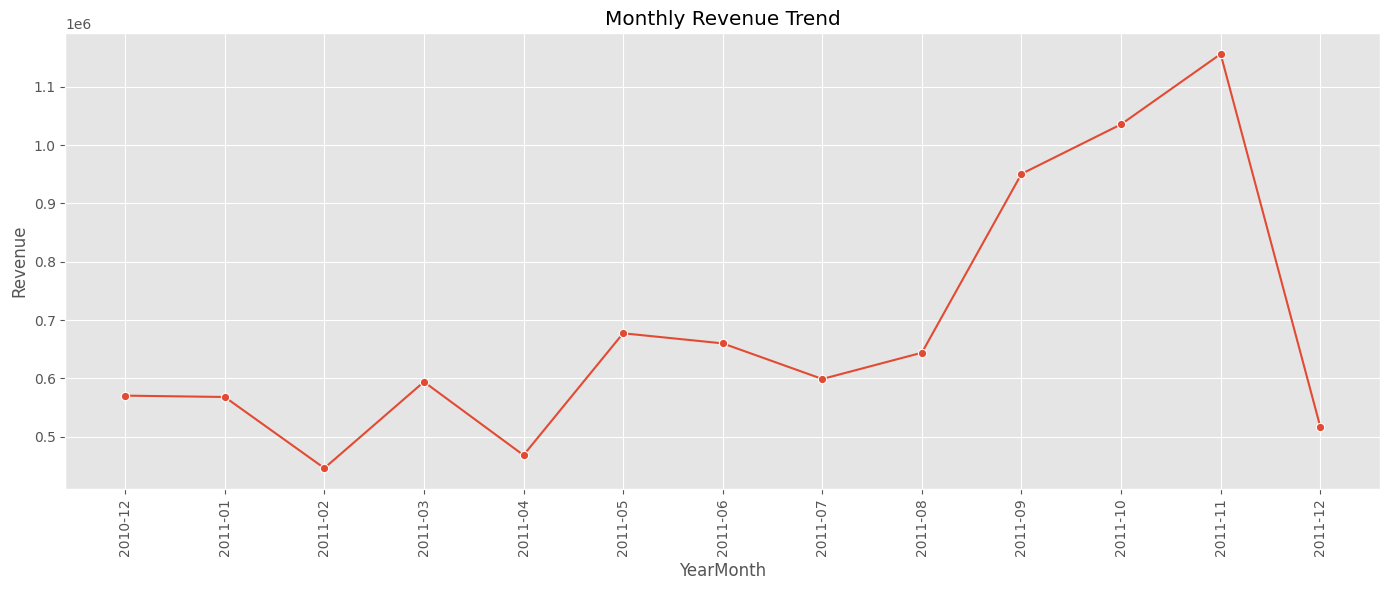

In [7]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_revenue,
    x="YearMonth",
    y="Revenue",
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Monthly Revenue Trend")

plt.tight_layout()

plt.show()

In [8]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

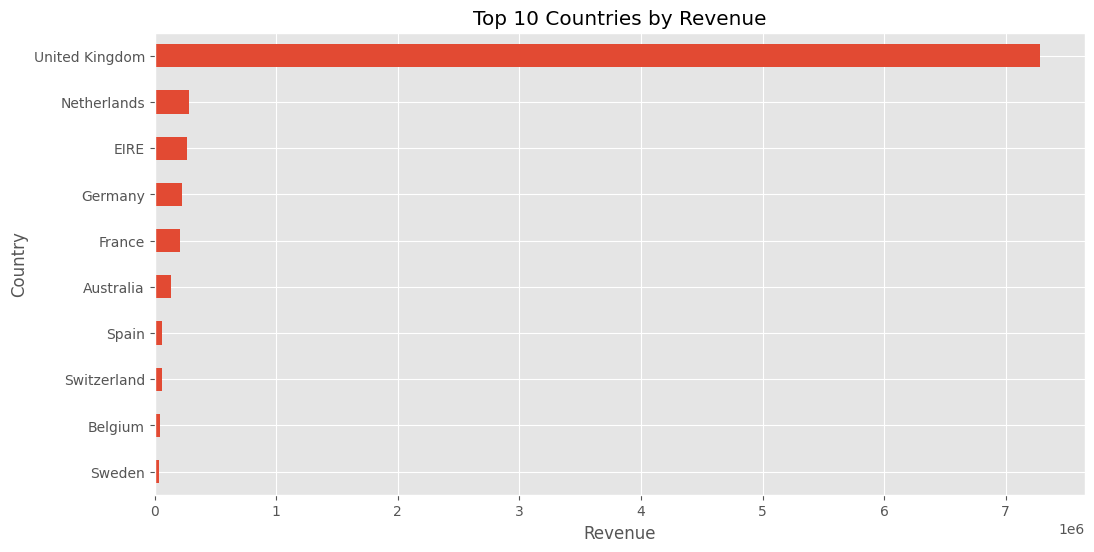

In [9]:
plt.figure(figsize=(12,6))

country_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue")

plt.show()

In [10]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64

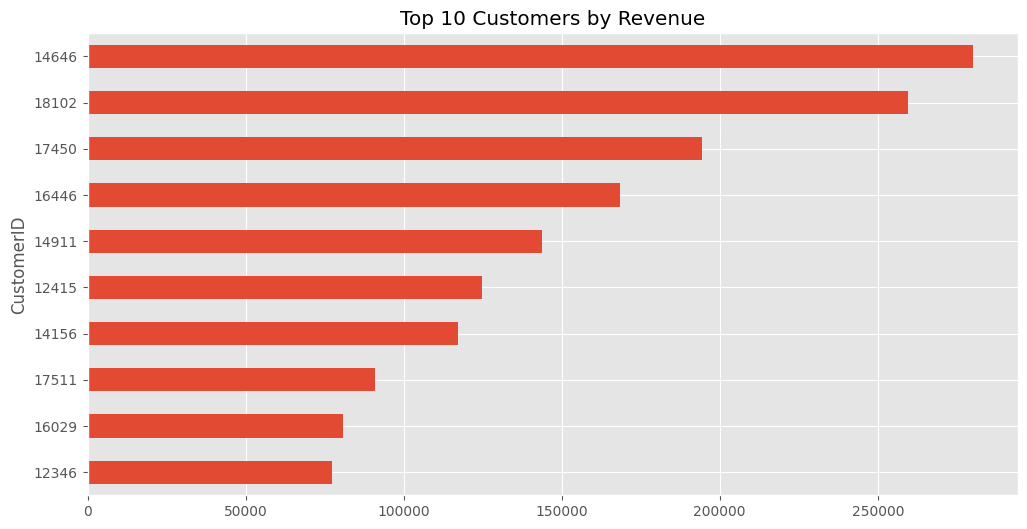

In [11]:
plt.figure(figsize=(12,6))

top_customers.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Customers by Revenue")

plt.show()

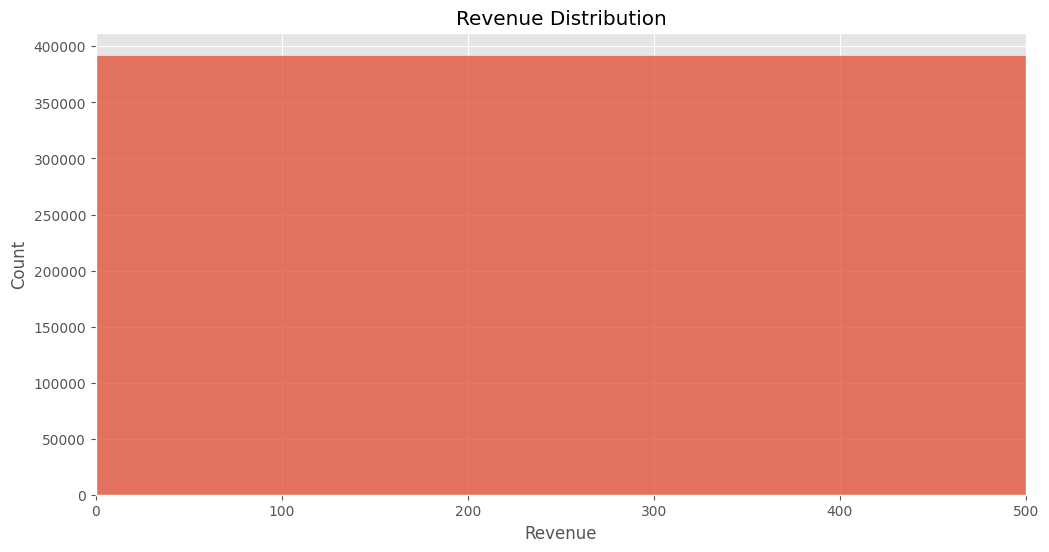

In [12]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["Revenue"],
    bins=100
)

plt.title("Revenue Distribution")

plt.xlim(0,500)

plt.show()

In [13]:
customer_spend = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

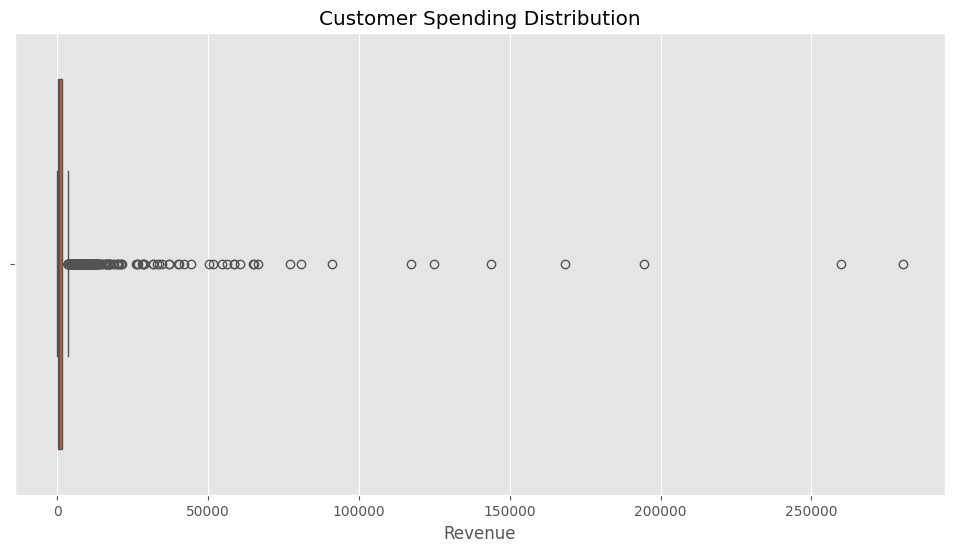

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=customer_spend
)

plt.title("Customer Spending Distribution")

plt.show()

In [15]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

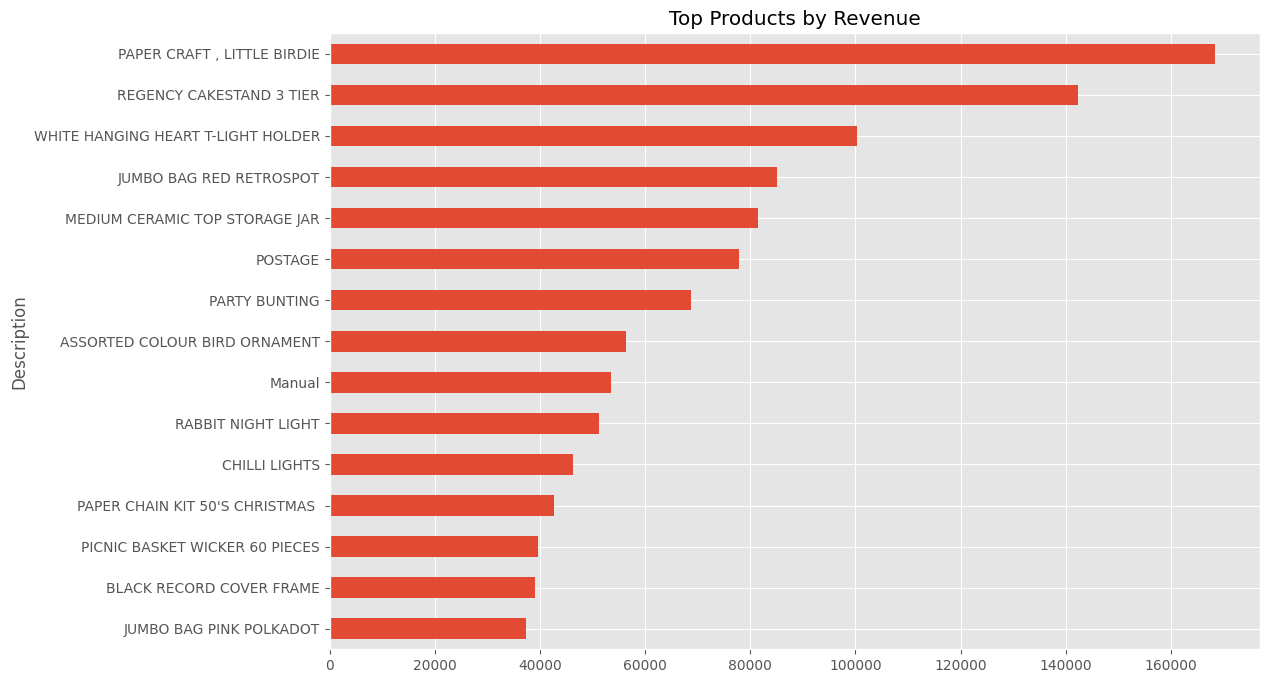

In [16]:
plt.figure(figsize=(12,8))

top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top Products by Revenue")

plt.show()

In [17]:
plt.savefig(
    "../outputs/charts/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Pareto Analysis

This analysis identifies how much revenue is generated by the top customers.

In [18]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_revenue["Revenue_Percentage"] = (
    customer_revenue["Revenue"] /
    customer_revenue["Revenue"].sum()
) * 100

customer_revenue["Cumulative_Revenue"] = (
    customer_revenue["Revenue_Percentage"]
    .cumsum()
)

customer_revenue.head()

,CustomerID,Revenue,Revenue_Percentage,Cumulative_Revenue
0,14646,280206.02,3.152914,3.152914
1,18102,259657.30,2.921697,6.074610
2,17450,194390.79,2.187310,8.261920
3,16446,168472.50,1.895674,10.157594
4,14911,143711.17,1.617056,11.774650


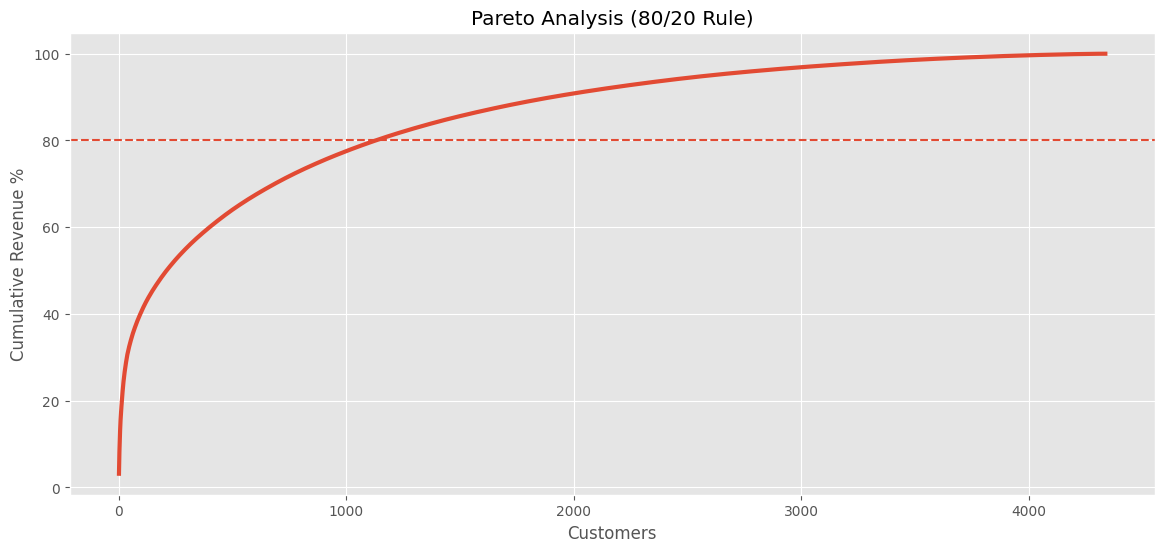

In [19]:
plt.figure(figsize=(14,6))

plt.plot(
    customer_revenue["Cumulative_Revenue"],
    linewidth=3
)

plt.axhline(
    y=80,
    linestyle="--"
)

plt.title("Pareto Analysis (80/20 Rule)")
plt.xlabel("Customers")
plt.ylabel("Cumulative Revenue %")

plt.show()

In [20]:
top_10_percent = int(len(customer_revenue) * 0.10)

top_revenue = (
    customer_revenue
    .head(top_10_percent)["Revenue"]
    .sum()
)

percentage = (
    top_revenue /
    customer_revenue["Revenue"].sum()
) * 100

print(
    f"Top 10% customers generate {percentage:.2f}% of total revenue"
)

Top 10% customers generate 61.41% of total revenue


In [21]:
monthly_orders = (
    df.groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reset_index()
)

monthly_orders.head()

,YearMonth,InvoiceNo
0,2010-12,1400
1,2011-01,987
2,2011-02,997
3,2011-03,1321
4,2011-04,1149


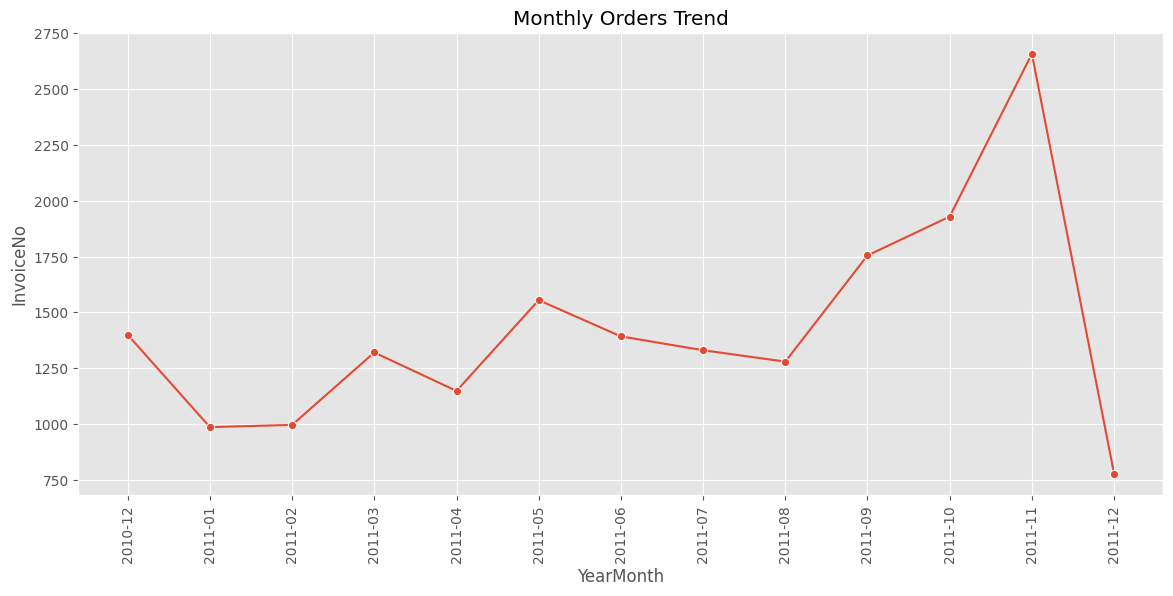

In [22]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_orders,
    x="YearMonth",
    y="InvoiceNo",
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Monthly Orders Trend")

plt.show()

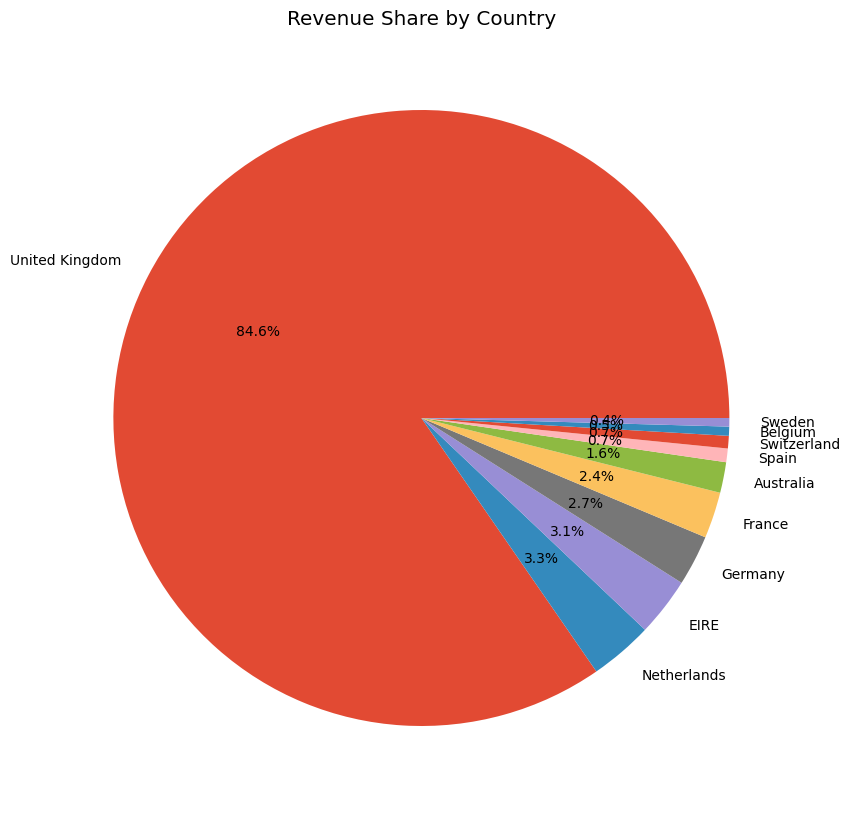

In [23]:
country_share = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,10))

plt.pie(
    country_share.values,
    labels=country_share.index,
    autopct="%1.1f%%"
)

plt.title("Revenue Share by Country")

plt.show()

In [24]:
import os

os.makedirs(
    "../outputs/charts",
    exist_ok=True
)

In [25]:
plt.savefig(
    "../outputs/charts/chart_name.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Executive Summary

## Key Findings

### Revenue
- Total revenue exceeds $8.8M.
- Strong sales growth observed in Q4 2011.

### Customers
- Revenue is highly concentrated among a small group of customers.
- Significant spending variation exists across customers.

### Geography
- United Kingdom dominates overall sales.
- International markets contribute a smaller share of revenue.

### Products
- A limited number of products drive a large proportion of revenue.

### Implications
These findings suggest that customer segmentation will provide significant value by identifying:

- VIP Customers
- Loyal Customers
- High Potential Customers
- At-Risk Customers
- Dormant Customers